# RFM Feature Engineering

## About this notebook
This notebook builds RFM (Recency, Frequency, Monetary) features from the
cleaned transaction data. Each customer is scored 1–5 on each dimension
and assigned to a business segment based on their behaviour.

Steps covered:
1. Calculate Recency, Frequency, and Monetary values per customer
2. Score each dimension using quantile-based binning (1–5)
3. Combine scores and assign customer segments
4. Save the RFM table for analysis in the next notebook


In [82]:
import pandas as pd

In [83]:
df = pd.read_csv("../data/online_retail_cleaned.csv")

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397884 entries, 0 to 397883
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397884 non-null  int64  
 1   StockCode    397884 non-null  object 
 2   Description  397884 non-null  object 
 3   Quantity     397884 non-null  int64  
 4   InvoiceDate  397884 non-null  object 
 5   UnitPrice    397884 non-null  float64
 6   CustomerID   397884 non-null  int64  
 7   Country      397884 non-null  object 
 8   Revenue      397884 non-null  float64
 9   YearMonth    397884 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 30.4+ MB


Creating a reference date to calculate recency (days since last purchase)
(usually the day after the last transaction in the dataset)

In [85]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate']) #converting the invoice date to datetime format

In [86]:
df['InvoiceDate'].max() 

Timestamp('2011-12-09 12:50:00')

In [87]:
snapshot_date = df['InvoiceDate'].max()
snapshot_date

Timestamp('2011-12-09 12:50:00')

In [88]:
#add 1 day to snapshot date to make sure we are not including 
# the last day in our recency calculation
snapshot_date = snapshot_date + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

## Calculate Recency (Customer Level)

Recency= Snapshot date - Customer's Last purchase date
- recency is the days since customer's last purchase

In [89]:
#get last purchase date for every customer
recency_df=df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency_df.head()

,CustomerID,InvoiceDate
0,12346,2011-01-18 10:01:00
1,12347,2011-12-07 15:52:00
2,12348,2011-09-25 13:13:00
3,12349,2011-11-21 09:51:00
4,12350,2011-02-02 16:01:00


In [90]:
#calculate recency in days
recency_df['Recency']=(snapshot_date - recency_df['InvoiceDate']).dt.days
recency_df.head()
#smaller value , more recent customer
#larger value, less recent customer

,CustomerID,InvoiceDate,Recency
0,12346,2011-01-18 10:01:00,326
1,12347,2011-12-07 15:52:00,2
2,12348,2011-09-25 13:13:00,75
3,12349,2011-11-21 09:51:00,19
4,12350,2011-02-02 16:01:00,310


Calculate Frequency 
- the number of unique invoices (orders) per customer

In [91]:
frequency_df=df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index(name='Frequency')
frequency_df.head()

#High frequency , loyal buyer
#Low frequency, one time buyer

,CustomerID,Frequency
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1


In [92]:
frequency_df['Frequency'].describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: Frequency, dtype: float64

Calculate Monetary
- total amount spent by each customer

In [93]:
#calculate total spend per customer
monetary_df=df.groupby('CustomerID')['Revenue'].sum().reset_index(name='Monetary')
monetary_df.head()

,CustomerID,Monetary
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40


In [94]:
monetary_df.describe()

,CustomerID,Monetary
count,4338.000000,4338.000000
mean,15300.408022,2054.266460
std,1721.808492,8989.230441
min,12346.000000,3.750000
25%,13813.250000,307.415000
50%,15299.500000,674.485000
75%,16778.750000,1661.740000
max,18287.000000,280206.020000


Important:
- high monetary value, high value customer 
- low monetary value, low value customer

## Merge Recency,Frequency,Monetary

In [95]:
#merge recency+frequency
rf_df=pd.merge(recency_df,frequency_df,on='CustomerID')
rf_df.head()

,CustomerID,InvoiceDate,Recency,Frequency
0,12346,2011-01-18 10:01:00,326,1
1,12347,2011-12-07 15:52:00,2,7
2,12348,2011-09-25 13:13:00,75,4
3,12349,2011-11-21 09:51:00,19,1
4,12350,2011-02-02 16:01:00,310,1


In [96]:
# merge monetary
rfm_df=pd.merge(rf_df,monetary_df,on='CustomerID')
rfm_df.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary
0,12346,2011-01-18 10:01:00,326,1,77183.60
1,12347,2011-12-07 15:52:00,2,7,4310.00
2,12348,2011-09-25 13:13:00,75,4,1797.24
3,12349,2011-11-21 09:51:00,19,1,1757.55
4,12350,2011-02-02 16:01:00,310,1,334.40


In [97]:
rfm_df.describe()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary
count,4338.000000,4338,4338.000000,4338.000000,4338.000000
mean,15300.408022,2011-09-08 11:38:59.045643008,92.536422,4.272015,2054.266460
min,12346.000000,2010-12-01 09:53:00,1.000000,1.000000,3.750000
25%,13813.250000,2011-07-20 19:18:00,18.000000,1.000000,307.415000
50%,15299.500000,2011-10-20 10:40:30,51.000000,2.000000,674.485000
75%,16778.750000,2011-11-22 11:05:45,142.000000,5.000000,1661.740000
max,18287.000000,2011-12-09 12:50:00,374.000000,209.000000,280206.020000
std,1721.808492,NaN,100.014169,7.697998,8989.230441


In [98]:
rfm_df.isnull().sum()

CustomerID     0
InvoiceDate    0
Recency        0
Frequency      0
Monetary       0
dtype: int64

## RFM SCORING

In [99]:
# Create RECENCY Score using quantiles
rfm_df['R_score']=pd.qcut(rfm_df['Recency'],q=5,labels=[5,4,3,2,1])

In [100]:
#Convert to integer
rfm_df['R_score']=rfm_df['R_score'].astype(int)
rfm_df.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary,R_score
0,12346,2011-01-18 10:01:00,326,1,77183.60,1
1,12347,2011-12-07 15:52:00,2,7,4310.00,5
2,12348,2011-09-25 13:13:00,75,4,1797.24,2
3,12349,2011-11-21 09:51:00,19,1,1757.55,4
4,12350,2011-02-02 16:01:00,310,1,334.40,1


In [101]:
# Check the distribution of R_score
rfm_df['R_score'].value_counts().sort_index()

R_score
1    865
2    843
3    858
4    904
5    868
Name: count, dtype: int64

In [102]:
#Score FREQUENCY
rfm_df['F_score'] = pd.qcut(
    rfm_df['Frequency'].rank(method='first'),
    q=5,
    labels=[1,2,3,4,5]
)

rfm_df['F_score'] = rfm_df['F_score'].astype(int)

In [103]:
# Check the distribution of F_score
rfm_df['F_score'].value_counts().sort_index()

F_score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64

In [104]:
#Create Monetary Score
rfm_df['M_score']=pd.qcut(rfm_df['Monetary'],
                          q=5,labels=[1,2,3,4,5])

In [105]:
#convert to integer
rfm_df['M_score']=rfm_df['M_score'].astype(int)

In [106]:
# Check the distribution of M_score
rfm_df['M_score'].value_counts().sort_index()

M_score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64

In [107]:
rfm_df.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary,R_score,F_score,M_score
0,12346,2011-01-18 10:01:00,326,1,77183.60,1,1,5
1,12347,2011-12-07 15:52:00,2,7,4310.00,5,5,5
2,12348,2011-09-25 13:13:00,75,4,1797.24,2,4,4
3,12349,2011-11-21 09:51:00,19,1,1757.55,4,1,4
4,12350,2011-02-02 16:01:00,310,1,334.40,1,1,2


## Combine RFM Scores

In [108]:
#create rfm score (string)
rfm_df['RFM_score']=(
rfm_df['R_score'].astype(str)+
rfm_df['F_score'].astype(str)+
rfm_df['M_score'].astype(str)
)

In [109]:
rfm_df.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,12346,2011-01-18 10:01:00,326,1,77183.60,1,1,5,115
1,12347,2011-12-07 15:52:00,2,7,4310.00,5,5,5,555
2,12348,2011-09-25 13:13:00,75,4,1797.24,2,4,4,244
3,12349,2011-11-21 09:51:00,19,1,1757.55,4,1,4,414
4,12350,2011-02-02 16:01:00,310,1,334.40,1,1,2,112


In [110]:
#overall rfm score (numeric)
rfm_df['RFM_total']=(
    rfm_df['R_score']+
    rfm_df['F_score']+
    rfm_df['M_score']
)

In [111]:
rfm_df.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_total
0,12346,2011-01-18 10:01:00,326,1,77183.60,1,1,5,115,7
1,12347,2011-12-07 15:52:00,2,7,4310.00,5,5,5,555,15
2,12348,2011-09-25 13:13:00,75,4,1797.24,2,4,4,244,10
3,12349,2011-11-21 09:51:00,19,1,1757.55,4,1,4,414,9
4,12350,2011-02-02 16:01:00,310,1,334.40,1,1,2,112,4


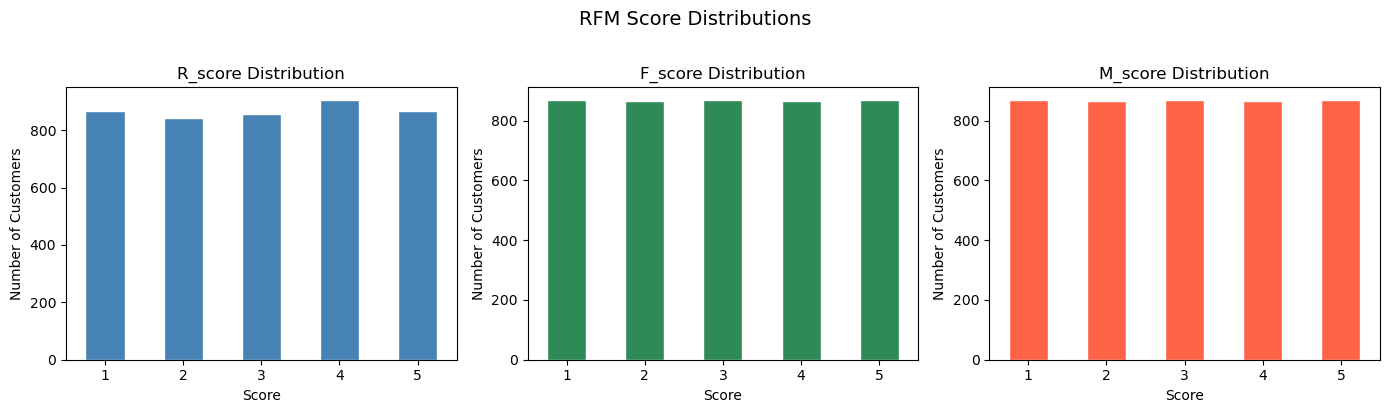

In [112]:
#distribution of RFM scores
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color in zip(axes, ['R_score', 'F_score', 'M_score'],
                           ['steelblue', 'seagreen', 'tomato']):
    rfm_df[col].value_counts().sort_index().plot(kind='bar', ax=ax,
                                                  color=color, edgecolor='white')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel('Score')
    ax.set_ylabel('Number of Customers')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('RFM Score Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Creating Customer Segments

In [113]:
def segment_customer(row):
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']

    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Promising'           # recent but haven't bought much yet
    elif r <= 2 and f >= 3:
        return 'At Risk'             # used to buy often but gone quiet
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm_df['Segment'] = rfm_df.apply(segment_customer, axis=1)

In [114]:
#segment distribution
rfm_df['Segment'].value_counts()

Segment
Champions          1139
Lost               1065
Loyal Customers     821
At Risk             643
Needs Attention     351
Promising           319
Name: count, dtype: int64

In [115]:
rfm_df.to_csv("../data/rfm_data.csv", index=False)